In [ ]:
from google.colab import files
uploaded=files.upload()

Saving tmdb_5000_movies.csv to tmdb_5000_movies (1).csv


**Section 1** - Data Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


Loading Dataset and display


In [ ]:
df=pd.read_csv("tmdb_5000_movies.csv")
df.shape

(4803, 20)

In [ ]:
df.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

In [ ]:
df.dtypes

,0
budget,int64
genres,object
homepage,object
id,int64
keywords,object
original_language,object
original_title,object
overview,object
popularity,float64
production_companies,object


In [ ]:
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [ ]:
#Checking missing values

df.isnull().sum()

,0
budget,0
genres,0
homepage,3091
id,0
keywords,0
original_language,0
original_title,0
overview,3
popularity,0
production_companies,0


In [ ]:
df['runtime'].skew()

np.float64(0.7159565062897394)

In [ ]:
#Creating binary target column


df['Hit']=np.where(df['vote_average']>=7,1,0)

Hit
0    3815
1     988
Name: count, dtype: int64


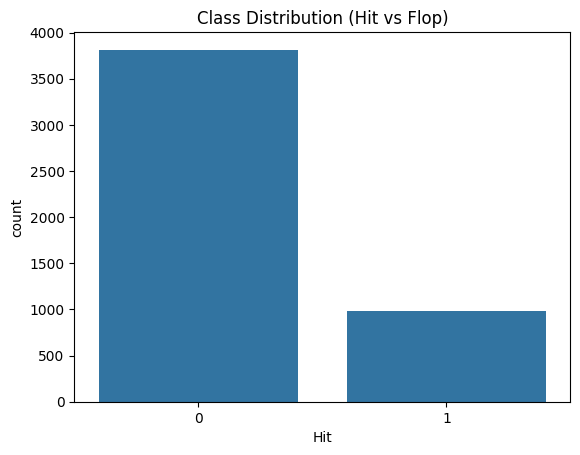

In [ ]:
#class distribution

print(df['Hit'].value_counts())

sns.countplot(x=df['Hit'])
plt.title("Class Distribution (Hit vs Flop)")
plt.show()

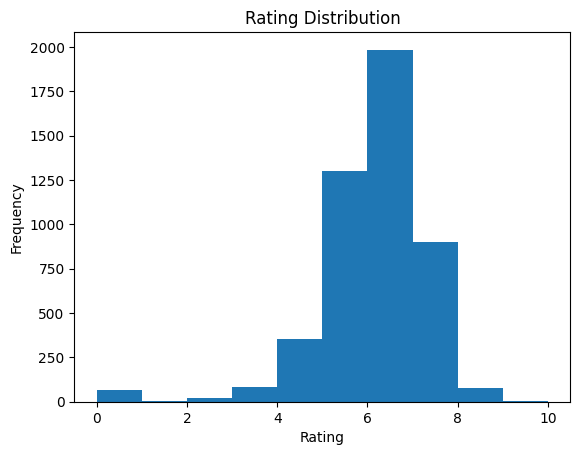

In [ ]:
#Rating distribution

plt.figure()
plt.hist(df['vote_average'],bins=10)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title("Rating Distribution")
plt.show()

**3 observation** -


*   most of the movies almost 50% are rated 5-7
*   Their are a very few movie almost 1 to 5 % that have been rated btw 0 to 1

*   Their is no movie who got a 10 rating





##### **Section 2 Data Preprocessing** #####

---



In [ ]:
df['original_language'].value_counts()

,count
original_language,
en,4505
fr,70
es,32
zh,27
de,27
hi,19
ja,16
it,14
cn,12


In [ ]:
df['original_language'] = df['original_language'].apply(
    lambda x: x if x == 'en' else 'other'
)

In [ ]:
df = pd.get_dummies(df, columns=['original_language'], drop_first=True)

In [ ]:
df[['original_language_other', 'Hit']].corr()

,original_language_other,Hit
original_language_other,1.000000,0.127469
Hit,0.127469,1.000000


In [ ]:
df['not_english'] = df['original_language_other'].astype(int)

In [ ]:
df[['runtime', 'Hit']].corr()

,runtime,Hit
runtime,1.000000,0.277667
Hit,0.277667,1.000000


In [ ]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

In [ ]:
df['release_year'] = df['release_date'].dt.year

In [ ]:
df[['release_year','Hit']].corr()

,release_year,Hit
release_year,1.00000,-0.18709
Hit,-0.18709,1.00000


In [ ]:
#dropping irrelevant columns

df.drop([
    'genres',
    'homepage',
    'id',
    'keywords',
    'original_title',
    'overview',
    'title',
    'production_companies',
    'production_countries',
    'status',
    'tagline',
    'vote_average',
    'release_date',
    'spoken_languages',
    'original_language_other'
], axis=1, inplace=True)

In [ ]:
#Encoding categorical value

df=pd.get_dummies(df,drop_first=True)

In [ ]:
#Handling misssing values

df['runtime'] = df['runtime'].fillna(df['runtime'].median())

In [ ]:
df['release_year'] = df['release_year'].fillna(df['release_year'].median())

In [ ]:
#Seperating x and y

X = df.drop("Hit", axis=1)
y = df["Hit"]


In [ ]:
# train test split(80-20)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Training logistic regression

model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
#Model Coefficient
#Coefficent meaning
# Positive coefficient → increases chance of being a Hit
# Negative coefficient → decreases chance of being a Hit
# Larger absolute value -> strong effect

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [-1.66070786]
Coefficients: [[-0.97558615  0.0189088  -0.19950889  0.63077049  1.5582592   0.30389797
  -0.40641646]]


In [ ]:
df.head()

,budget,popularity,revenue,runtime,vote_count,Hit,not_english,release_year
0,237000000,150.437577,2787965087,162.0,11800,1,0,2009.0
1,300000000,139.082615,961000000,169.0,4500,0,0,2007.0
2,245000000,107.376788,880674609,148.0,4466,0,0,2015.0
3,250000000,112.312950,1084939099,165.0,9106,1,0,2012.0
4,260000000,43.926995,284139100,132.0,2124,0,0,2012.0


In [ ]:
#Predict dataset

y_pred=model.predict(X_test)


In [ ]:
#Model evaluation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8407908428720083
Precision: 0.6929824561403509
Recall: 0.4010152284263959
F1 Score: 0.5080385852090032


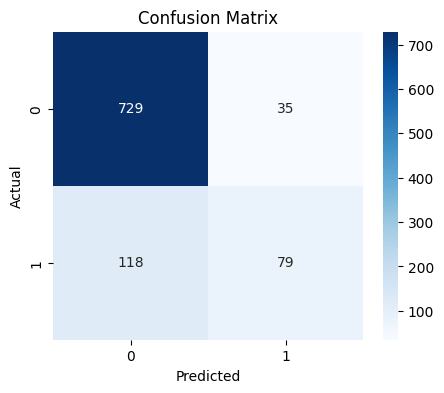

In [ ]:
#Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Q. Why accuracy alone is not enough?**

 Accuracty doesnt tells us


    how many positives were detected
    how many important cases we missed
    whether model is biased towards one class

it only tells us total correctness







**Q. Which metric matters more**

if we have to care about predicting hits than recall is important

if we have to avoid false hype than precision matters most

if we want balanced output than f1 score matters more

# Section 5 Buiseness Intrepetation

**Q. What factors influences movie success most**

the factor which have large positive coefficient contribute towards movie success in our case it is the vote_couint that affects teh most than runtime than original_language



**Q. Is the dataset balanced?**

if we see the recall so it is 40%, hence our model misses 60% of actual hits so yes our model is biased towards predicting flop




**Q. Would you trust this model for production? Why?**

no we cannot fully trust, because recall is low, if we are using our model to predict blockbuster movies than our model will miss 60% of them